# XGBoost Explainability — SHAP & Counterfactual Analysis
## MS Subtype Classification (RRMS, SPMS, PPMS)

---

### Objective

This notebook provides a **complete explainability analysis** of the XGBoost classifier for MS subtype prediction using two complementary techniques:

| Technique | Question Answered | Output |
|-----------|------------------|--------|
| **SHAP** | *Why did the model make this prediction?* | Feature contributions (direction + magnitude) |
| **Counterfactual (DiCE)** | *What would change the prediction?* | Actionable feature modifications |

### Subtypes

- **RRMS** — Relapsing-Remitting MS (most common, defined by clinical relapses)
- **SPMS** — Secondary Progressive MS (evolves from RRMS, gradual worsening)
- **PPMS** — Primary Progressive MS (progressive from onset, zero relapses)

---

## 1. Setup and Configuration

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import shap
import dice_ml

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from xgboost import XGBClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 300, 'font.size': 11,
    'axes.titlesize': 13, 'axes.labelsize': 11,
    'figure.figsize': (10, 6), 'axes.grid': True, 'grid.alpha': 0.3,
    'axes.spines.top': False, 'axes.spines.right': False,
})

COLORS = {'PPMS': '#4CAF50', 'RRMS': '#2196F3', 'SPMS': '#FF5722'}
ORDER = ['RRMS', 'SPMS', 'PPMS']

print(f"SHAP version: {shap.__version__}")
print("Setup complete.")

C:\Users\Mustaqeem Uddin\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP version: 0.51.0
Setup complete.


---
## 2. Data Preparation & XGBoost Model

We load the MS dataset (525 samples, 16 features), preprocess, and train the XGBoost classifier.

In [ ]:
# Load and prepare data
df = pd.read_csv('../datasets/ms_dataset.csv')
feature_cols = [c for c in df.columns if c != 'subtype']
X = df[feature_cols]
y = df['subtype']

le = LabelEncoder()
y_encoded = le.fit_transform(y)
class_names = le.classes_

# Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=RANDOM_STATE, stratify=y_encoded
)

# Imputation
imputer = SimpleImputer(strategy='median')
X_train_ready = pd.DataFrame(imputer.fit_transform(X_train), columns=feature_cols, index=X_train.index)
X_test_ready = pd.DataFrame(imputer.transform(X_test), columns=feature_cols, index=X_test.index)
sample_weights = compute_sample_weight('balanced', y_train)

print(f"Train: {X_train_ready.shape}, Test: {X_test_ready.shape}")
print(f"Classes: {list(class_names)}")
print(f"Class distribution (test): {dict(zip(class_names, np.bincount(y_test)))}")

Train: (420, 16), Test: (105, 16)
Classes: ['PPMS', 'RRMS', 'SPMS']
Class distribution (test): {'PPMS': np.int64(25), 'RRMS': np.int64(55), 'SPMS': np.int64(25)}


In [ ]:
# Train XGBoost
model = XGBClassifier(
    objective='multi:softprob', n_estimators=300,
    learning_rate=0.1, max_depth=5, subsample=0.8,
    colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0,
    eval_metric='mlogloss', use_label_encoder=False,
    random_state=RANDOM_STATE, n_jobs=-1
)
model.fit(X_train_ready, y_train, sample_weight=sample_weights, verbose=False)

y_pred = model.predict(X_test_ready)
print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Test Macro F1: {f1_score(y_test, y_pred, average='macro'):.4f}")
print()
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

Test Accuracy: 0.8952
Test Macro F1: 0.8698

              precision    recall  f1-score   support

        PPMS     0.7857    0.8800    0.8302        25
        RRMS     0.9811    0.9455    0.9630        55
        SPMS     0.8333    0.8000    0.8163        25

    accuracy                         0.8952       105
   macro avg     0.8667    0.8752    0.8698       105
weighted avg     0.8994    0.8952    0.8964       105



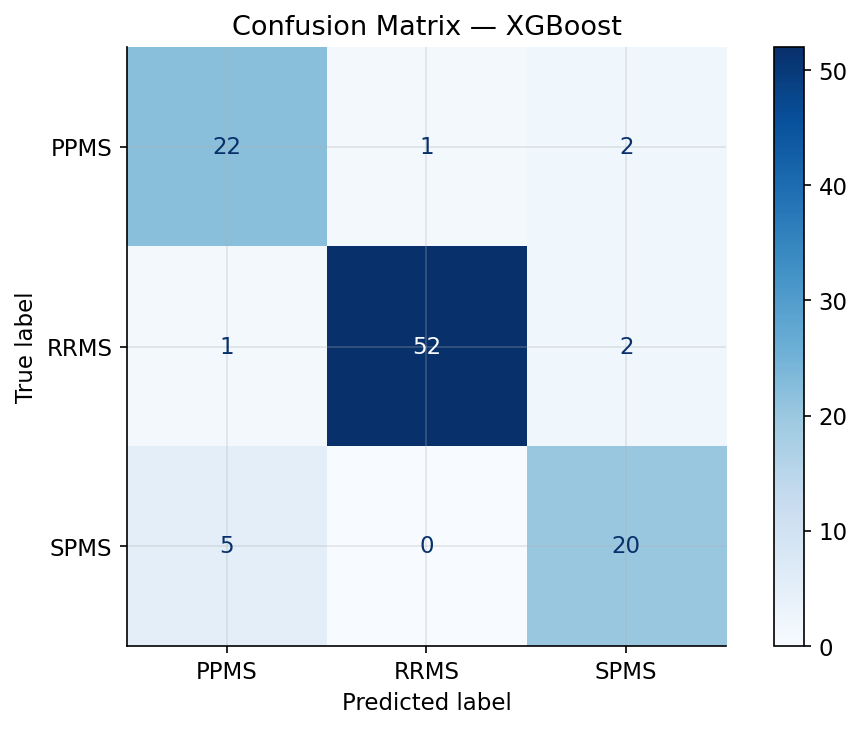

In [ ]:
# Confusion Matrix
fig, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('Confusion Matrix — XGBoost')
plt.tight_layout()
plt.show()

---
# Part A: SHAP Explainability

SHAP (SHapley Additive exPlanations) uses game theory to assign each feature a contribution score for every prediction. For tree models, `TreeExplainer` computes **exact** Shapley values efficiently.

---

## 3. Computing SHAP Values

In [ ]:
# Compute SHAP values using TreeExplainer
explainer = shap.TreeExplainer(model)
shap_values_raw = explainer.shap_values(X_test_ready)

# Handle different SHAP output formats
if isinstance(shap_values_raw, list):
    shap_values_list = shap_values_raw
elif shap_values_raw.ndim == 3:
    shap_values_list = [shap_values_raw[:, :, i] for i in range(shap_values_raw.shape[2])]
else:
    shap_values_list = [shap_values_raw]

print(f"SHAP computed for {len(shap_values_list)} classes, shape per class: {shap_values_list[0].shape}")
print(f"Classes: {list(class_names)}")

SHAP computed for 3 classes, shape per class: (105, 16)
Classes: ['PPMS', 'RRMS', 'SPMS']


---
## 4. Global Feature Importance

Mean |SHAP| across all test samples and classes — shows which features matter most **overall**.

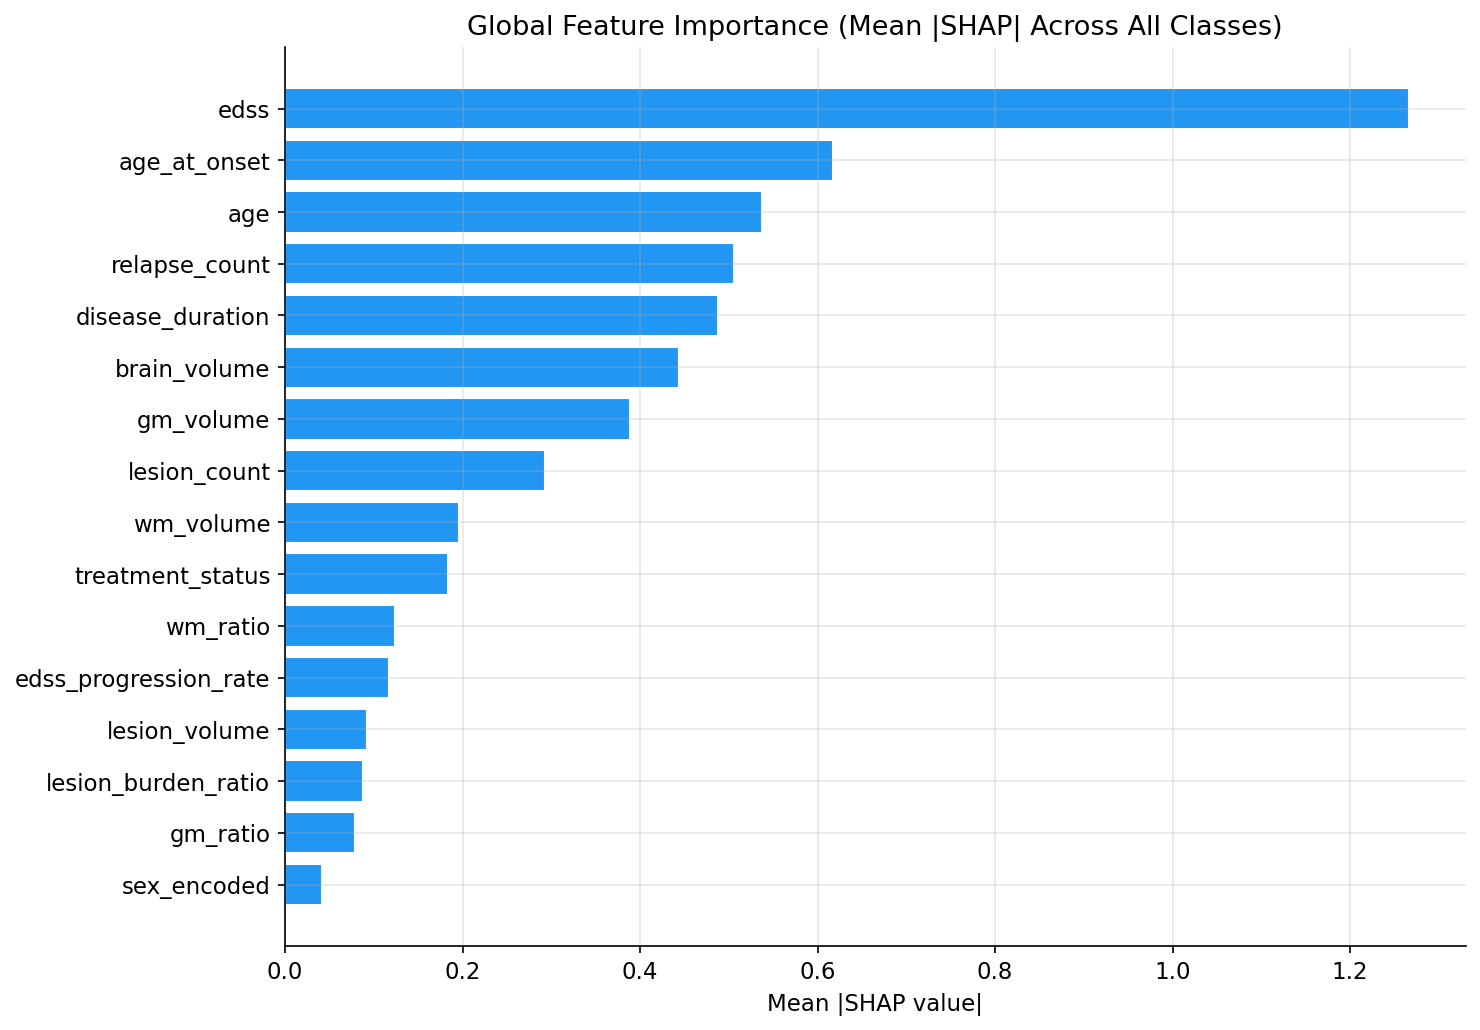


Top 5 features:
  edss                           1.2667
  age_at_onset                   0.6175
  age                            0.5378
  relapse_count                  0.5059
  disease_duration               0.4873


In [ ]:
# Global mean |SHAP| importance
mean_abs_shap = np.mean([np.abs(sv) for sv in shap_values_list], axis=0).mean(axis=0)
importance_df = pd.DataFrame({'feature': feature_cols, 'mean_abs_shap': mean_abs_shap})
importance_df = importance_df.sort_values('mean_abs_shap', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(importance_df['feature'], importance_df['mean_abs_shap'], color='#2196F3', edgecolor='white')
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('Global Feature Importance (Mean |SHAP| Across All Classes)')
plt.tight_layout()
plt.show()

print("\nTop 5 features:")
for _, row in importance_df.tail(5).iloc[::-1].iterrows():
    print(f"  {row['feature']:30s} {row['mean_abs_shap']:.4f}")

---
## 5. Per-Class SHAP Summary (Beeswarm Plots)

Each subplot shows how feature values push predictions toward/away from a specific class.

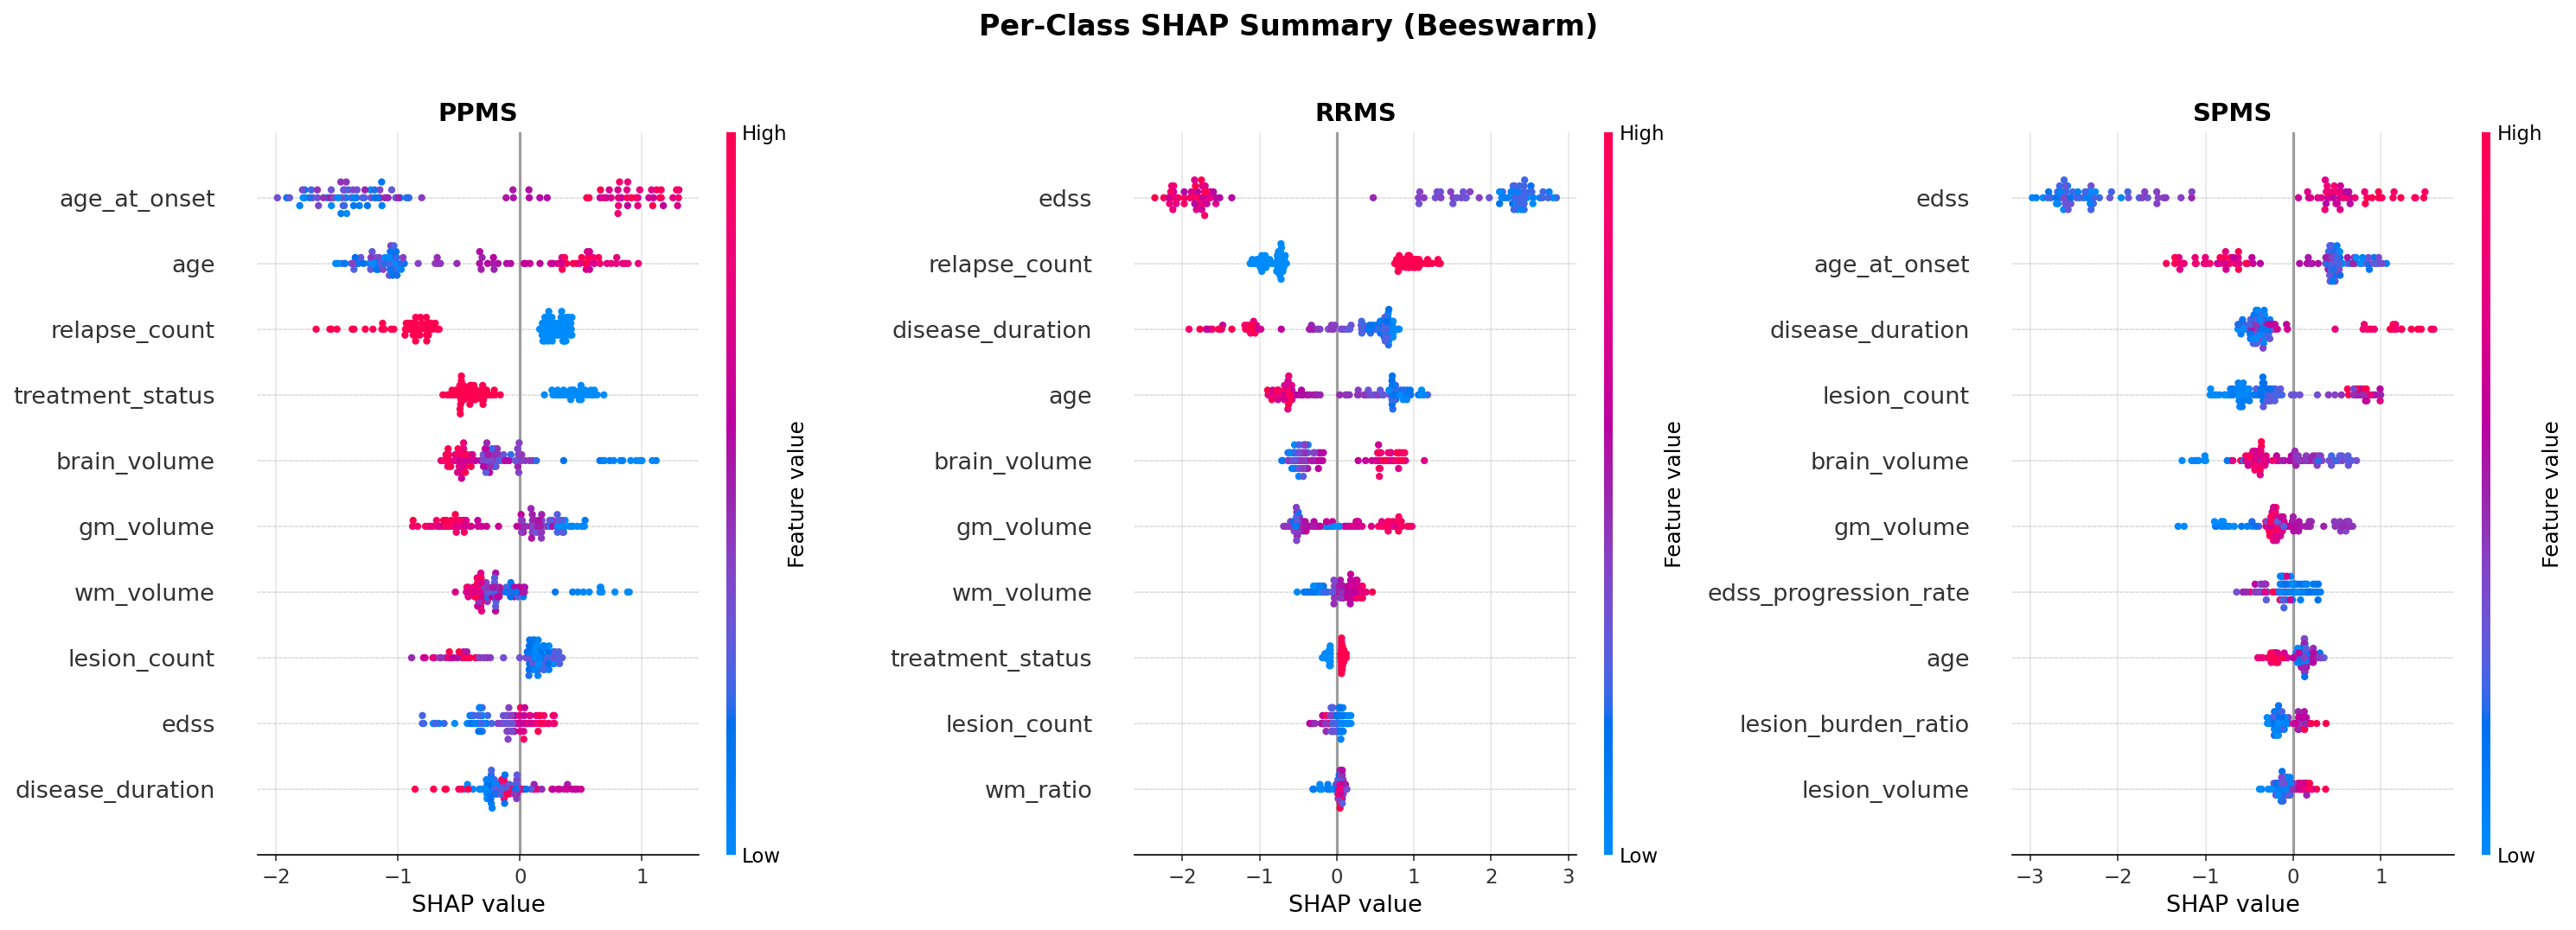

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
for idx, name in enumerate(class_names):
    plt.sca(axes[idx])
    shap.summary_plot(
        shap_values_list[idx], X_test_ready,
        show=False, plot_size=None, max_display=10
    )
    axes[idx].set_title(f'{name}', fontsize=14, fontweight='bold')
    axes[idx].set_xlabel('SHAP value')
plt.suptitle('Per-Class SHAP Summary (Beeswarm)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 6. Per-Class Feature Importance (Bar Plots)

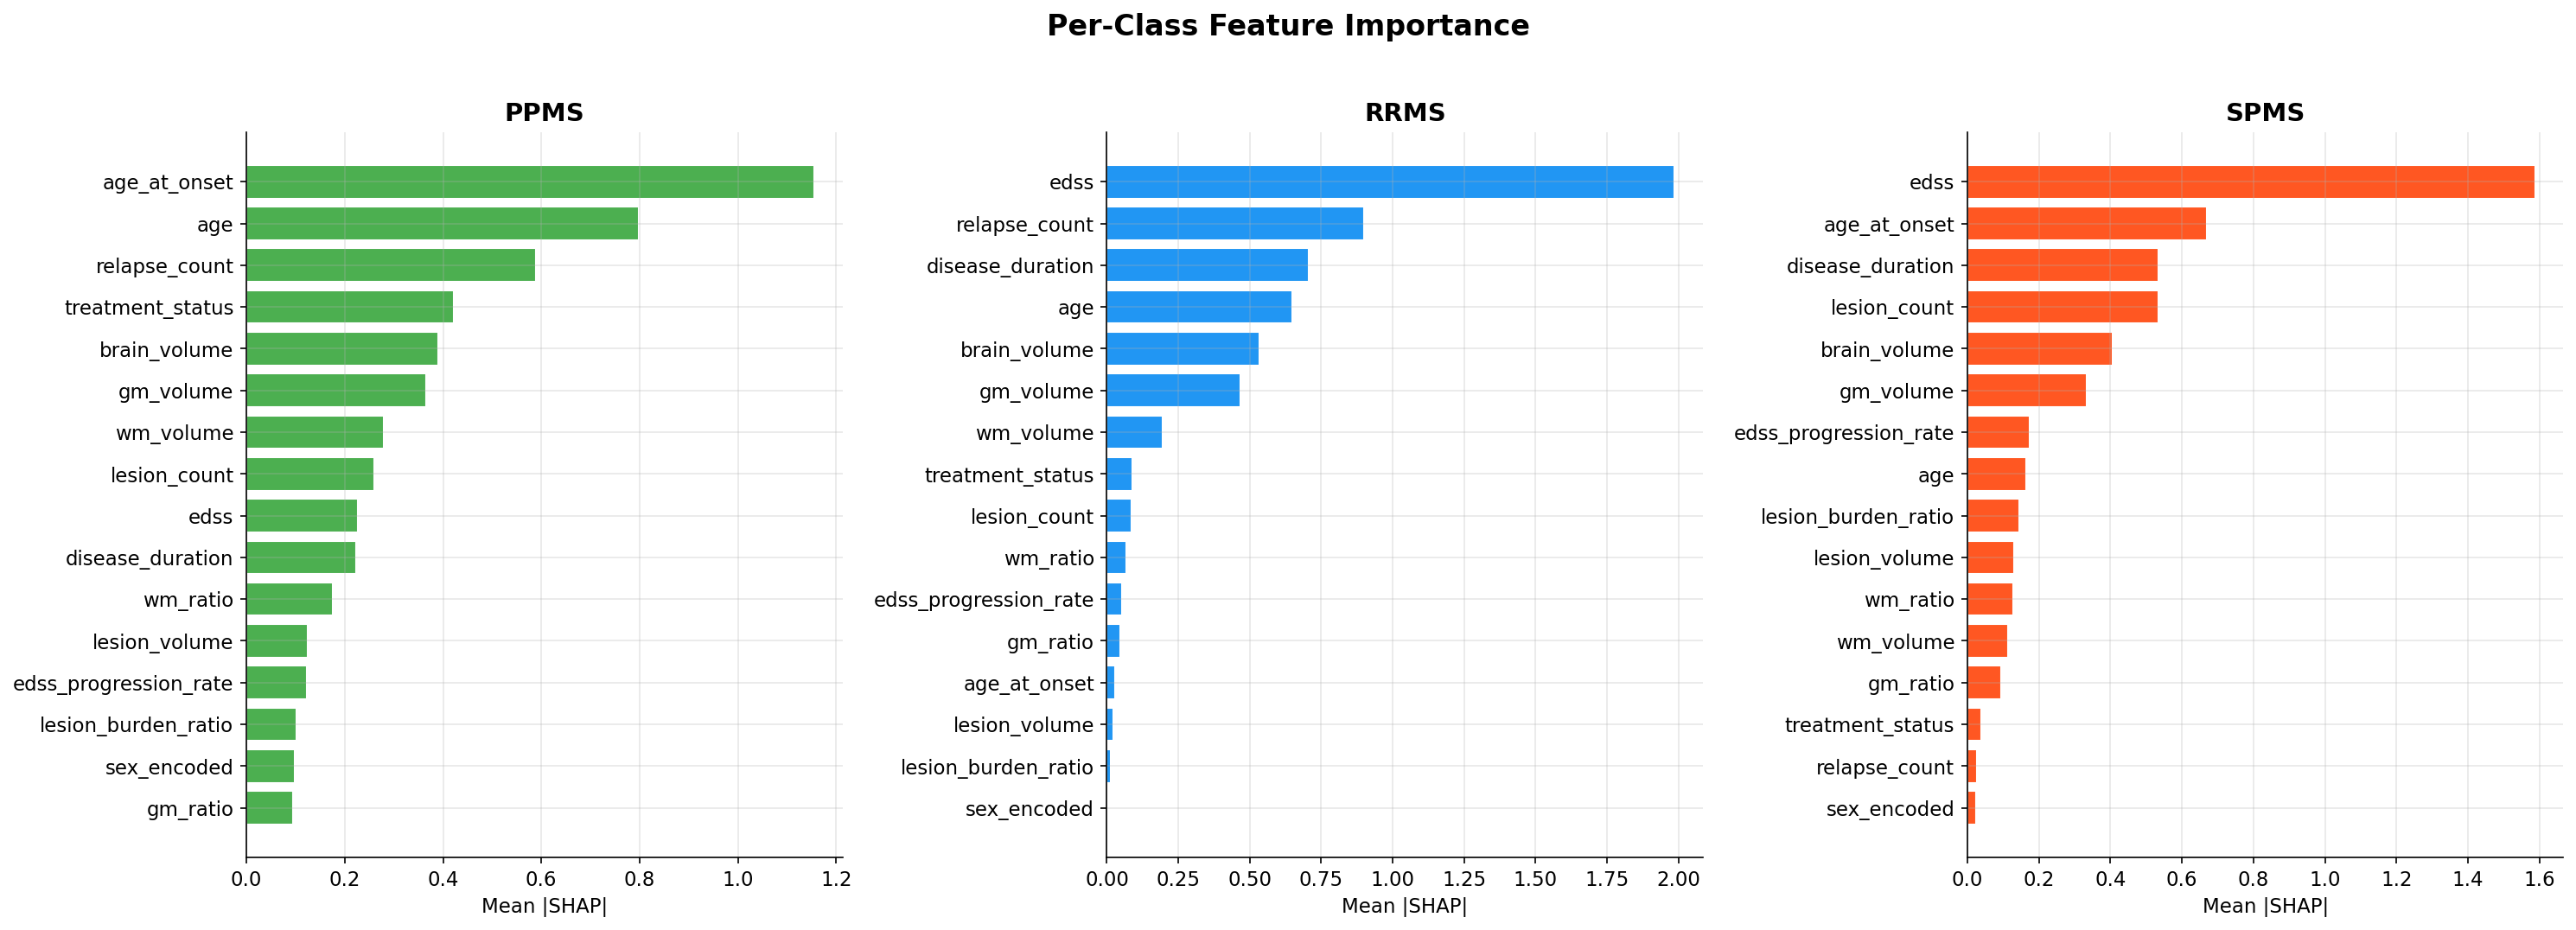

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
for idx, name in enumerate(class_names):
    mean_shap = np.abs(shap_values_list[idx]).mean(axis=0)
    order = np.argsort(mean_shap)
    axes[idx].barh(
        np.array(feature_cols)[order], mean_shap[order],
        color=COLORS.get(name, '#666'), edgecolor='white'
    )
    axes[idx].set_title(f'{name}', fontsize=14, fontweight='bold')
    axes[idx].set_xlabel('Mean |SHAP|')
plt.suptitle('Per-Class Feature Importance', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 7. Individual Patient Explanations (Waterfall Plots)

Waterfall plots for one correctly classified patient per subtype.


Waterfall: PPMS patient (test #0)


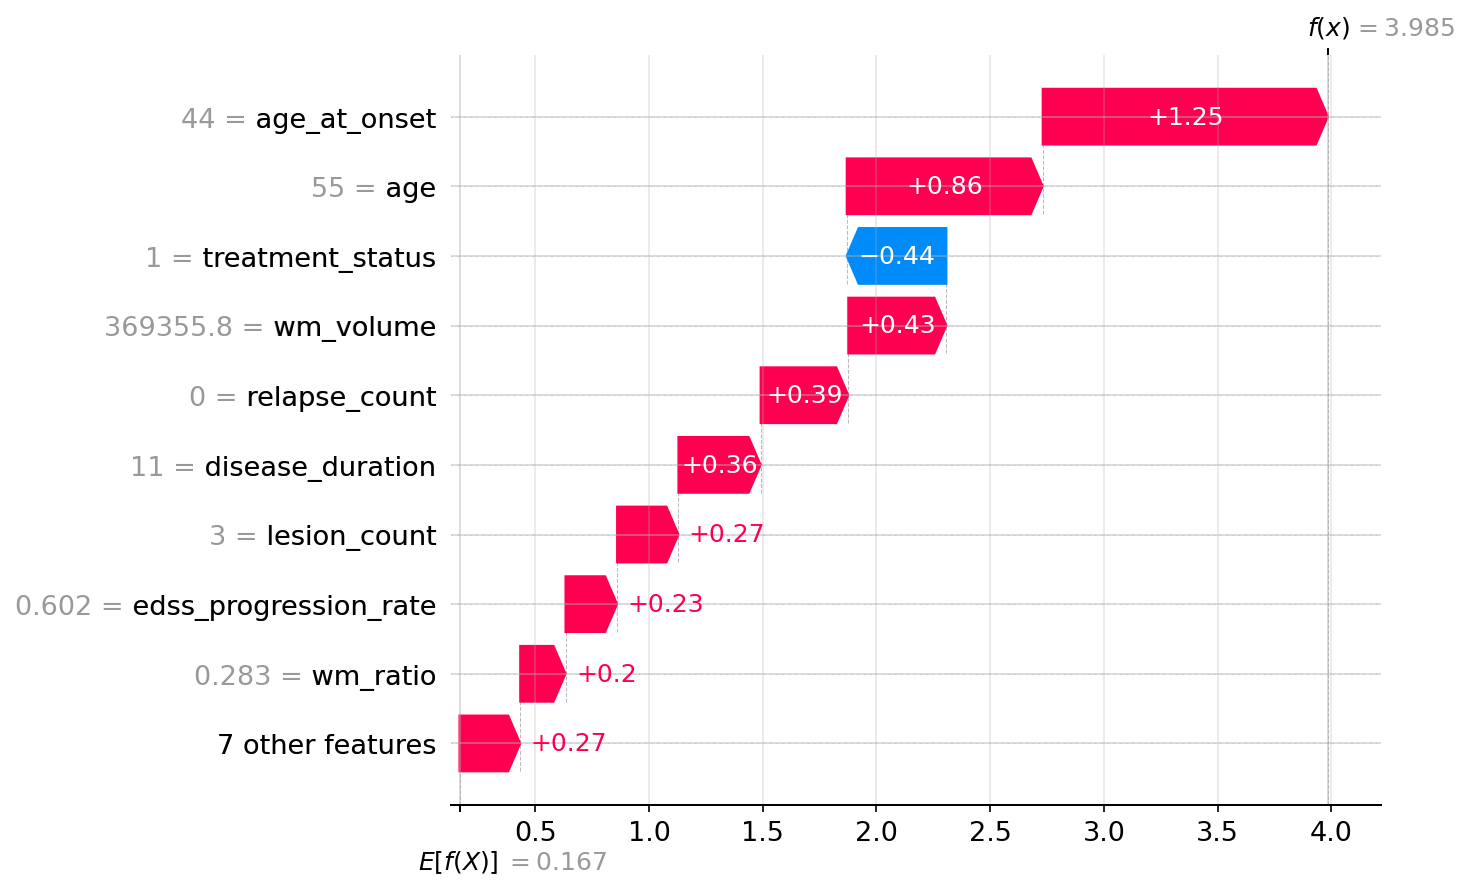


Waterfall: RRMS patient (test #1)


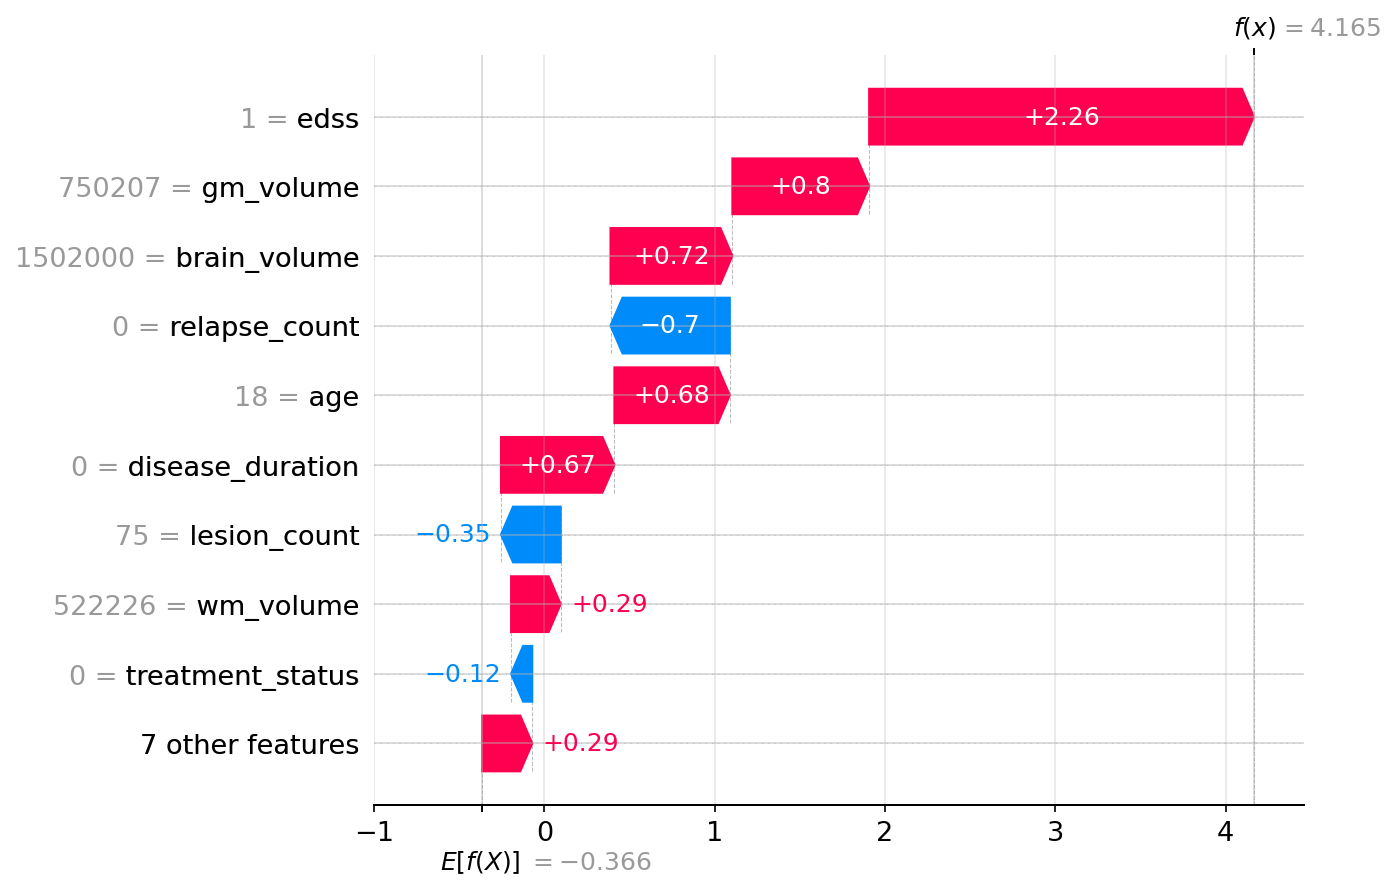


Waterfall: SPMS patient (test #6)


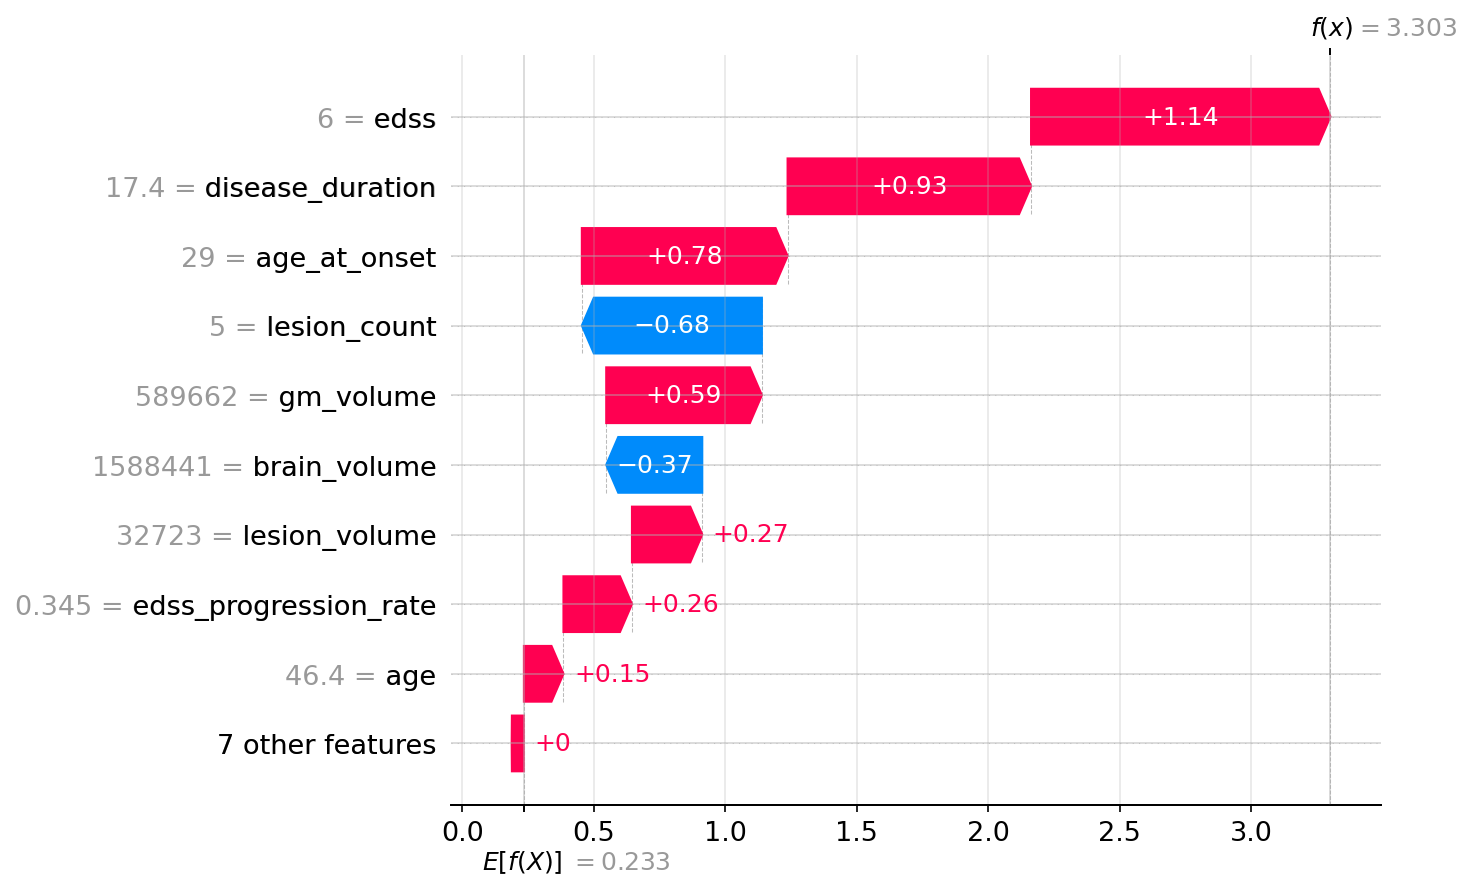

In [ ]:
# Find one correctly classified sample per class
for class_idx, class_name in enumerate(class_names):
    correct_mask = (y_test == class_idx) & (y_pred == class_idx)
    correct_indices = np.where(correct_mask)[0]
    if len(correct_indices) == 0:
        print(f"No correctly classified {class_name} patients.")
        continue
    sample_idx = correct_indices[0]
    sv = shap_values_list[class_idx][sample_idx]
    base = explainer.expected_value[class_idx] if hasattr(explainer.expected_value, '__len__') else explainer.expected_value
    explanation = shap.Explanation(
        values=sv, base_values=base,
        data=X_test_ready.iloc[sample_idx].values,
        feature_names=feature_cols
    )
    print(f"\n{'='*60}")
    print(f"Waterfall: {class_name} patient (test #{sample_idx})")
    print(f"{'='*60}")
    shap.plots.waterfall(explanation, show=True)

---
## 8. SHAP Force Plot (Individual)

Compact visualization of feature contributions for a single prediction.

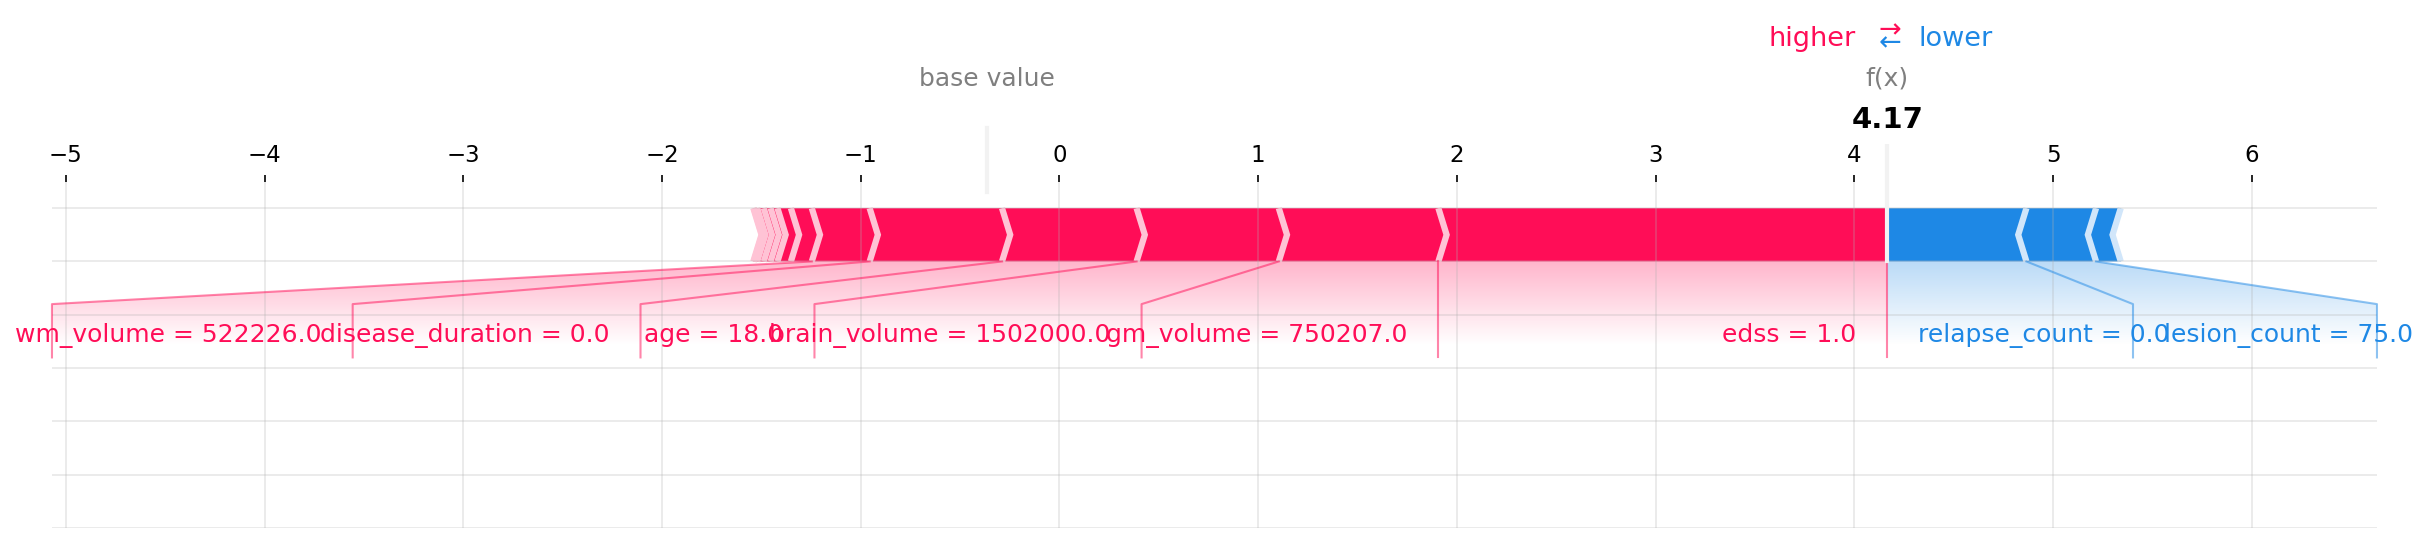

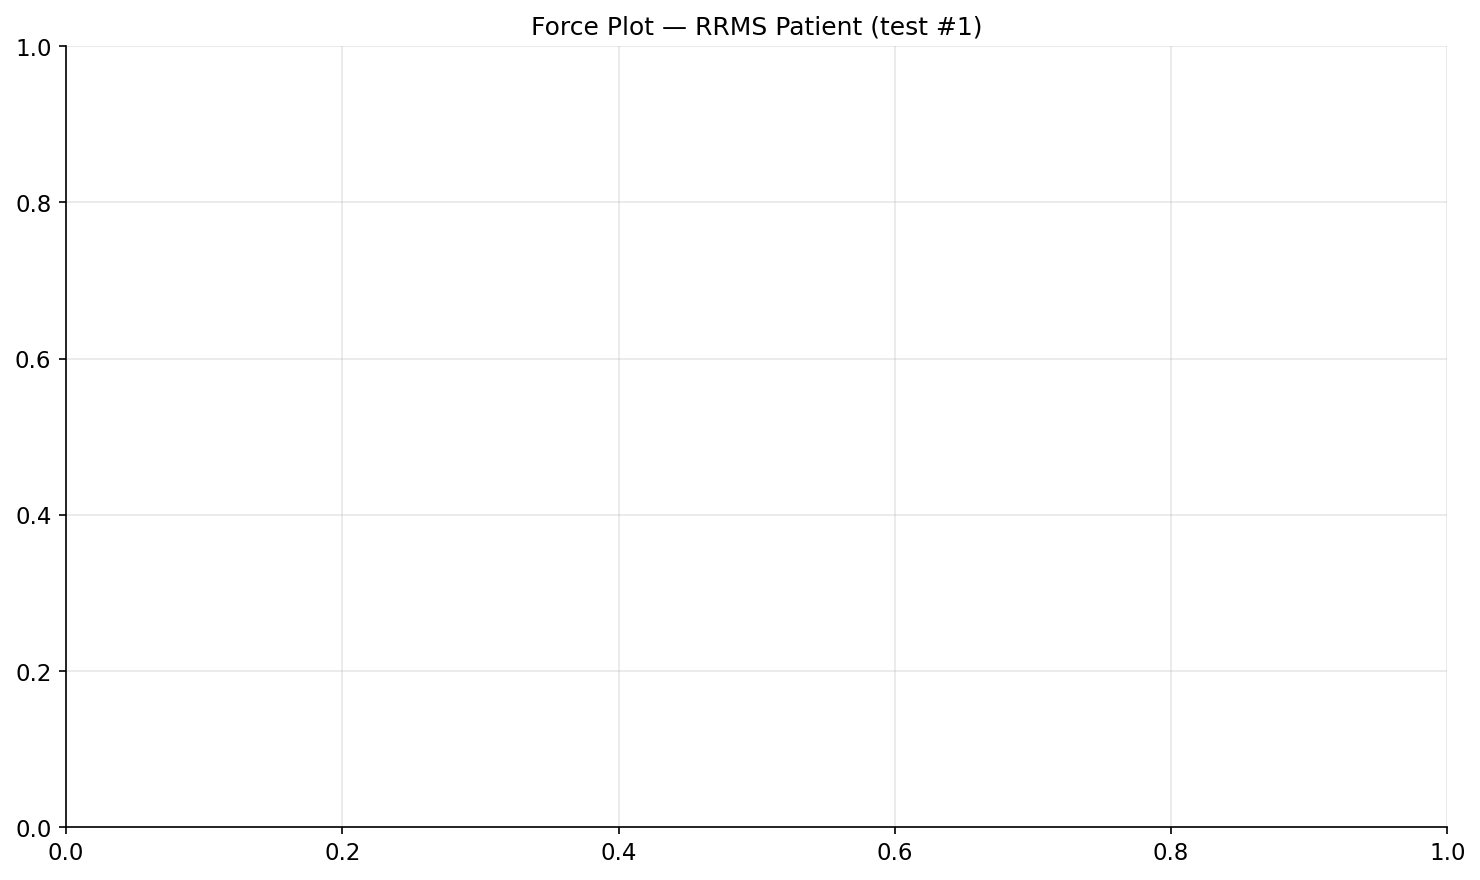

In [ ]:
# Force plot for the first correctly classified RRMS patient
rrms_idx = np.where(class_names == 'RRMS')[0][0]
correct_rrms = np.where((y_test == rrms_idx) & (y_pred == rrms_idx))[0]
if len(correct_rrms) > 0:
    sample_idx = correct_rrms[0]
    base = explainer.expected_value[rrms_idx] if hasattr(explainer.expected_value, '__len__') else explainer.expected_value
    shap.initjs()
    shap.force_plot(
        base, shap_values_list[rrms_idx][sample_idx],
        X_test_ready.iloc[sample_idx], feature_names=feature_cols, matplotlib=True
    )
    plt.title(f'Force Plot — RRMS Patient (test #{sample_idx})', fontsize=12)
    plt.tight_layout()
    plt.show()

---
# Part B: Counterfactual Explanations (DiCE)

DiCE generates *actionable* counterfactuals: minimal feature changes that would flip the model's prediction to a different class.

---

## 9. DiCE Setup

In [ ]:
# Prepare DiCE training data
train_for_dice = X_train_ready.copy()
train_for_dice['subtype'] = y_train

continuous_features = [c for c in feature_cols if c not in ['sex_encoded', 'treatment_status']]
class_index_map = {name: idx for idx, name in enumerate(class_names)}

# Create DiCE objects
dice_data = dice_ml.Data(
    dataframe=train_for_dice,
    continuous_features=continuous_features,
    outcome_name='subtype'
)
dice_model = dice_ml.Model(model=model, backend='sklearn')
dice_exp = dice_ml.Dice(dice_data, dice_model, method='random')

print(f"DiCE ready. Continuous features: {len(continuous_features)}")
print(f"Class mapping: {class_index_map}")

DiCE ready. Continuous features: 14
Class mapping: {'PPMS': 0, 'RRMS': 1, 'SPMS': 2}


---
## 10. Counterfactual Explanations Per Subtype

For each correctly classified patient, we generate counterfactuals showing what would need to change to flip the prediction to a clinically relevant alternative subtype.

In [ ]:
# Define transitions: source -> target
transitions = {
    'PPMS': 'RRMS',   # Progressive -> Relapsing
    'RRMS': 'SPMS',   # Relapsing -> Secondary Progressive
    'SPMS': 'RRMS',   # Secondary Progressive -> Relapsing
}

cf_results = {}
for source_name, target_name in transitions.items():
    source_idx = class_index_map[source_name]
    target_idx = class_index_map[target_name]
    correct_mask = (y_test == source_idx) & (y_pred == source_idx)
    correct_indices = np.where(correct_mask)[0]
    if len(correct_indices) == 0:
        print(f"No correctly classified {source_name} patients — skipping.")
        continue
    sample_idx = correct_indices[0]
    query = X_test_ready.iloc[[sample_idx]]
    print(f"\n{'='*60}")
    print(f"{source_name} Patient (test #{sample_idx}) → Target: {target_name}")
    print(f"{'='*60}")
    try:
        cf = dice_exp.generate_counterfactuals(
            query, total_CFs=3, desired_class=int(target_idx),
            features_to_vary=continuous_features
        )
        cf.visualize_as_dataframe(show_only_changes=True)
        cf_results[source_name] = cf
    except Exception as e:
        print(f"  Error: {e}")


PPMS Patient (test #0) → Target: RRMS



  0%|          | 0/1 [00:00<?, ?it/s]


100%|██████████| 1/1 [00:00<00:00,  7.79it/s]


100%|██████████| 1/1 [00:00<00:00,  7.72it/s]

Query instance (original outcome : 0)


,age,sex_encoded,age_at_onset,edss,disease_duration,relapse_count,treatment_status,brain_volume,gm_volume,wm_volume,lesion_count,lesion_volume,edss_progression_rate,gm_ratio,wm_ratio,lesion_burden_ratio,subtype
0,55.0,1.0,44.0,3.5,11.0,0.0,1.0,1303211.5,583393.8125,369355.8125,3.0,17658.5,0.6016,0.4477,0.2834,0.01355,0



Diverse Counterfactual set (new outcome: 1)


,age,sex_encoded,age_at_onset,edss,disease_duration,relapse_count,treatment_status,brain_volume,gm_volume,wm_volume,lesion_count,lesion_volume,edss_progression_rate,gm_ratio,wm_ratio,lesion_burden_ratio,subtype
0,-,-,33.7,-,-,2.0,-,-,-,-,-,-,-,-,-,-,1.0
1,18.7,-,-,-,-,1.1,-,-,-,-,-,-,-,-,-,-,1.0
2,-,-,13.1,-,-,1.6,-,-,-,-,-,-,-,-,-,-,1.0



RRMS Patient (test #1) → Target: SPMS



  0%|          | 0/1 [00:00<?, ?it/s]


100%|██████████| 1/1 [00:00<00:00,  9.50it/s]


100%|██████████| 1/1 [00:00<00:00,  9.43it/s]

Query instance (original outcome : 1)


,age,sex_encoded,age_at_onset,edss,disease_duration,relapse_count,treatment_status,brain_volume,gm_volume,wm_volume,lesion_count,lesion_volume,edss_progression_rate,gm_ratio,wm_ratio,lesion_burden_ratio,subtype
0,18.0,0.0,18.0,1.0,0.0,0.0,0.0,1502000.0,750207.0,522226.0,75.0,5213.0,0.435645,0.499472,0.347687,0.003471,1



Diverse Counterfactual set (new outcome: 2)


,age,sex_encoded,age_at_onset,edss,disease_duration,relapse_count,treatment_status,brain_volume,gm_volume,wm_volume,lesion_count,lesion_volume,edss_progression_rate,gm_ratio,wm_ratio,lesion_burden_ratio,subtype
0,-,-,-,-,26.3,-,-,-,-,-,-,-,-,-,-,-,2.0
1,-,-,-,5.2,-,-,-,-,-,-,-,41500.7,-,-,-,-,2.0
2,-,-,-,6.2,-,-,-,-,-,-,-,-,-,-,-,-,2.0



SPMS Patient (test #6) → Target: RRMS



  0%|          | 0/1 [00:00<?, ?it/s]


100%|██████████| 1/1 [00:00<00:00,  9.69it/s]


100%|██████████| 1/1 [00:00<00:00,  9.62it/s]

Query instance (original outcome : 2)


,age,sex_encoded,age_at_onset,edss,disease_duration,relapse_count,treatment_status,brain_volume,gm_volume,wm_volume,lesion_count,lesion_volume,edss_progression_rate,gm_ratio,wm_ratio,lesion_burden_ratio,subtype
0,46.400002,0.0,29.0,6.0,17.4,0.0,0.0,1588441.0,589662.0,434781.0,5.0,32723.0,0.344828,0.371221,0.273716,0.020601,2



Diverse Counterfactual set (new outcome: 1)


,age,sex_encoded,age_at_onset,edss,disease_duration,relapse_count,treatment_status,brain_volume,gm_volume,wm_volume,lesion_count,lesion_volume,edss_progression_rate,gm_ratio,wm_ratio,lesion_burden_ratio,subtype
0,-,-,-,0.6,8.7,-,-,-,-,-,-,-,-,-,-,-,1.0
1,-,-,-,2.0,-,-,-,-,-,-,-,-,7.29791739,-,-,-,1.0
2,-,-,-,2.2,-,-,-,-,-,-,-,-,2.80661047,-,-,-,1.0


---
## 11. Counterfactual Feature Change Summary

Which features are most frequently modified across all counterfactuals?

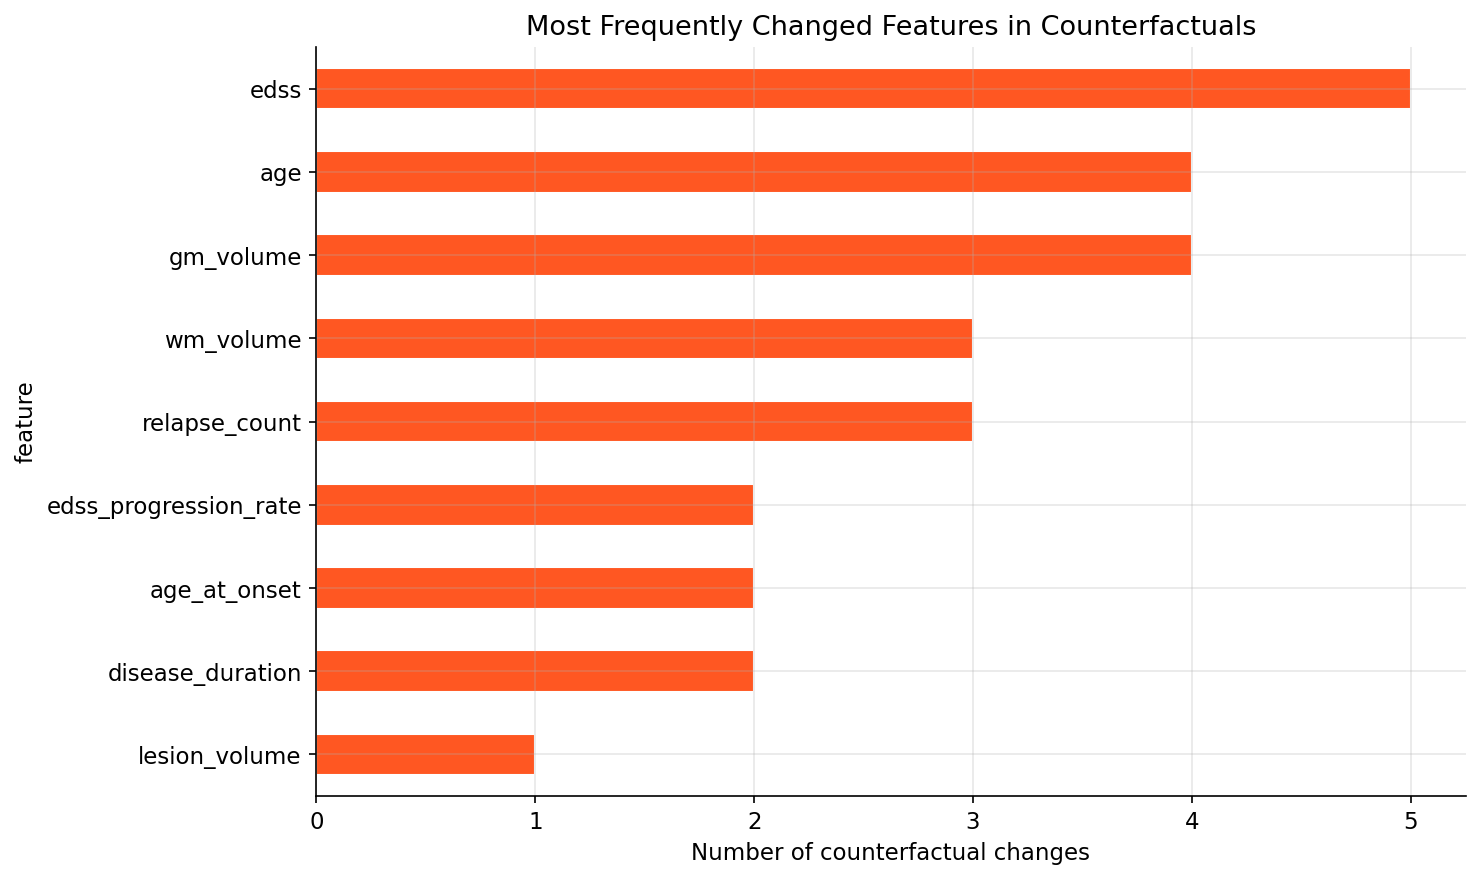


Change frequency:
feature
edss                     5
age                      4
gm_volume                4
wm_volume                3
relapse_count            3
age_at_onset             2
disease_duration         2
edss_progression_rate    2
lesion_volume            1


In [ ]:
# Aggregate counterfactual changes
all_changes = []
for source_name, cf_obj in cf_results.items():
    try:
        cf_list = cf_obj.cf_examples_list
        for cf_example in cf_list:
            orig = cf_example.test_instance_df[feature_cols].iloc[0]
            cfs_df = cf_example.final_cfs_df
            if cfs_df is None or len(cfs_df) == 0:
                continue
            for _, cf_row in cfs_df.iterrows():
                for feat in feature_cols:
                    if feat in cf_row.index:
                        orig_val = float(orig[feat])
                        cf_val = float(cf_row[feat])
                        if abs(orig_val - cf_val) > 1e-6:
                            all_changes.append({
                                'source': source_name,
                                'feature': feat,
                                'original': orig_val,
                                'counterfactual': cf_val,
                                'delta': cf_val - orig_val
                            })
    except Exception as e:
        print(f"Error processing {source_name}: {e}")

if all_changes:
    changes_df = pd.DataFrame(all_changes)
    freq = changes_df['feature'].value_counts()
    fig, ax = plt.subplots(figsize=(10, 6))
    freq.sort_values().plot.barh(ax=ax, color='#FF5722', edgecolor='white')
    ax.set_xlabel('Number of counterfactual changes')
    ax.set_title('Most Frequently Changed Features in Counterfactuals')
    plt.tight_layout()
    plt.show()
    print("\nChange frequency:")
    print(freq.to_string())
else:
    print("No counterfactual changes were generated.")

---
## 12. Summary

### Key Findings

**SHAP Analysis:**
- Identified the most important features driving MS subtype classification
- Per-class analysis reveals which features distinguish each subtype
- Individual patient explanations provide clinical transparency

**Counterfactual Analysis:**
- Generated actionable counterfactuals for each MS subtype
- Identified minimal feature changes needed to flip predictions
- Provides clinicians with "what-if" scenarios for treatment planning

### Clinical Relevance
The combination of SHAP (explaining *why*) and DiCE counterfactuals (explaining *what would change*) provides a comprehensive explainability framework for MS subtype classification, supporting clinical decision-making.

---